In [1]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import streamlit as st 
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
import os 
from langchain_google_genai import ChatGoogleGenerativeAI
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel, Field
import operator
from langgraph.graph import StateGraph,START, END,MessagesState

from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver
# model=ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash-lite",   # or gemini-2.0-pro, 1.5-pro, etc.
#     temperature=0.2)
#from langchain_core.messages.utils import trim_messages,count_tokens_approximately
#model=ChatOpenAI()
llm=ChatOpenAI(model="gpt-4.1-mini")

c:\Users\Dharmendra Vartika\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langchain_community.tools.tavily_search import TavilySearchResults


from langgraph.graph import StateGraph, START, END

In [3]:
docs = (
    PyPDFLoader("Company_Policies.pdf").load()
    + PyPDFLoader("Company_Profile.pdf").load()
    + PyPDFLoader("Product_and_Pricing.pdf").load()
)
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [4]:
class SelfRAGState(TypedDict):
    question: str
    context: str
    answer: str
    verdict: Literal["good", "revise", "retrieve"]
    iteration: int

MAX_ITERATIONS = 3

In [6]:
# ----------------------------
# Structured Evaluation Output
# ----------------------------

class Evaluation(BaseModel):
    verdict: Literal["good", "revise", "retrieve"] = Field(
        description="Is the answer good, needs revision, or needs more retrieval?"
    )
    reasoning: str

In [7]:
# ----------------------------
# 1️⃣ Retrieve
# ----------------------------

def retrieve(state: SelfRAGState):
    # Replace with real vector search
    docs =  retriever.invoke(state["question"])
    s= "\n\n---\n\n".join(d.page_content for d in docs).strip()
    return {"context": s}

In [8]:
from langchain_core.messages import HumanMessage

In [9]:
# ----------------------------
# 2️⃣ Generate
# ----------------------------

def generate(state: SelfRAGState):
    prompt = f"""
    Answer strictly using the provided context.
    If context is insufficient, say so.

    Context:
    {state['context']}

    Question:
    {state['question']}
    """
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"answer": response.content}

In [10]:
# ----------------------------
# 3️⃣ Self-Evaluate (Structured)
# ----------------------------

def self_evaluate(state: SelfRAGState):
    structured_llm = llm.with_structured_output(Evaluation)

    eval_prompt = f"""
    Evaluate the answer based on the context.

    Context:
    {state['context']}

    Question:
    {state['question']}

    Answer:
    {state['answer']}

    Rules:
    - If answer is correct and grounded → verdict = good
    - If reasoning is weak but context sufficient → verdict = revise
    - If context insufficient → verdict = retrieve
    """

    result = structured_llm.invoke(eval_prompt)

    return {
        "verdict": result.verdict,
        "iteration": state["iteration"] + 1
    }

In [11]:
# ----------------------------
# 4️⃣ Revise Node
# ----------------------------

def revise(state: SelfRAGState):
    prompt = f"""
    Improve the answer below.
    Make it fully grounded in the context.

    Context:
    {state['context']}

    Question:
    {state['question']}

    Previous Answer:
    {state['answer']}
    """
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"answer": response.content}

In [12]:
# ----------------------------
# 5️⃣ Router
# ----------------------------

def route(state: SelfRAGState):
    if state["iteration"] >= MAX_ITERATIONS:
        return END

    if state["verdict"] == "good":
        return END
    elif state["verdict"] == "revise":
        return "revise"
    elif state["verdict"] == "retrieve":
        return "retrieve"

In [22]:
# ----------------------------
# Build Graph
# ----------------------------

builder = StateGraph(SelfRAGState)

builder.add_node("retrieve", retrieve)
builder.add_node("generate", generate)
builder.add_node("self_evaluate", self_evaluate)
builder.add_node("revise", revise)

builder.set_entry_point("retrieve")

builder.add_edge("retrieve", "generate")
builder.add_edge("generate", "self_evaluate")
builder.add_edge("revise", "self_evaluate")

builder.add_conditional_edges("self_evaluate", route,  {
        "revise": "revise",
        "retrieve": "retrieve",
        END :END
        
    })

graph = builder.compile()

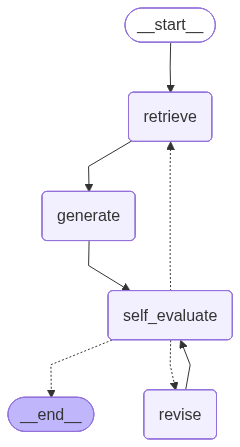

In [23]:
graph 

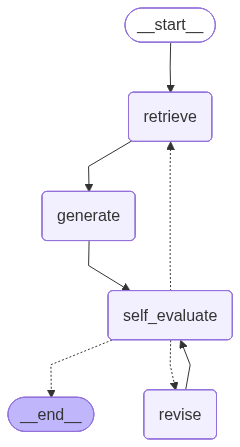

In [24]:
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)


In [40]:
result = graph.invoke({
    "question": "explain self rag ?",
    "iteration": 0
})
result

{'question': 'explain self rag ?',
 'context': '\x7f\nQuery logging and audit trails\n\x7f\nData residency and compliance controls\n\x7f\nPolicy-based response filtering\n\x7f\nIntegration with enterprise IAM systems\n\n---\n\n\x7f\nSick Leave: 10 working days per year\n\x7f\nCasual Leave: 6 working days per year\n\x7f\nMaternity Leave: As per statutory norms\n\x7f\nUnused annual leave may be carried forward up to 30 days\nWorkplace Conduct\nEmployees are expected to act professionally and ethically at all times.\n\x7f\nMaintain confidentiality of company and client information\n\x7f\nAvoid conflicts of interest\n\x7f\nNo acceptance of bribes or unethical gifts\n\x7f\nCompliance with information security policies\nDisciplinary Actions\nAny violation of company policies may result in disciplinary action.\n\n---\n\n\x7f\nWritten warning\n\x7f\nSuspension\n\x7f\nTermination of employment in severe cases\n\n---\n\nNexaInsight – Business Analytics & Reporting\nNexaInsight helps leadership a

In [37]:
result

{'question': 'how many annual leaves do employees get?',
 'context': '\x7f\nSick Leave: 10 working days per year\n\x7f\nCasual Leave: 6 working days per year\n\x7f\nMaternity Leave: As per statutory norms\n\x7f\nUnused annual leave may be carried forward up to 30 days\nWorkplace Conduct\nEmployees are expected to act professionally and ethically at all times.\n\x7f\nMaintain confidentiality of company and client information\n\x7f\nAvoid conflicts of interest\n\x7f\nNo acceptance of bribes or unethical gifts\n\x7f\nCompliance with information security policies\nDisciplinary Actions\nAny violation of company policies may result in disciplinary action.\n\n---\n\nNexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-har

In [30]:
result

{'question': 'Explain Self-RAG',
 'context': '\x7f\nQuery logging and audit trails\n\x7f\nData residency and compliance controls\n\x7f\nPolicy-based response filtering\n\x7f\nIntegration with enterprise IAM systems\n\n---\n\nNexaInsight – Business Analytics & Reporting\nNexaInsight helps leadership and business teams analyze structured business data using natural\nlanguage queries instead of traditional dashboards.\nIt connects with internal databases and BI tools to generate explainable insights.\n\x7f\nNatural language querying over structured data\n\x7f\nAutomated KPI summaries and trend analysis\n\x7f\nScheduled weekly and monthly reports\n\x7f\nExport to PDF and Excel\n\x7f\nRole-based visibility for leadership and managers\nNexaSupport – Customer Support Automation\n\n---\n\n\x7f\nAutomated FAQ and troubleshooting responses\n\x7f\nMulti-channel support (chat, email, web)\n\x7f\nConfidence-based human escalation\n\x7f\nTicket tagging and prioritization\n\x7f\nAnalytics on resoluti